# Goldmansachs Project

### This project analyzes customer transaction behavior using the Goldman Sachs dataset.
 The primary goal is to clean the data, understand customer activity patterns, and categorize accounts into Active, Inactive, and Dormant based on transaction frequency, recency, balance, and inflow trends.

 Objectives:-

1. Clean and preprocess customer and transaction data.

2. Analyze account activity trends.

3. Define metrics that determine Active vs Inactive accounts.

4. Create new behavioral categories (frequency, inflow, balance).

5. Extract insights to help Goldman Sachs improve customer engagement.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading and Initial Exploration

Here we load the dataset and inspect its structure.
This step helps us understand:

Number of rows and columns

Data types

Missing values

Basic statistics of numerical variables

In [4]:
df = pd.read_csv("goldman_sachs.csv")
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,33,CUST6549,ACC12334,Credit,Withdrawal,Savings Account,Firm C,Central,Manager 1,21-10-2023,87480.05448,74008.43310,0.729101,319,200
1,177,CUST2942,ACC52650,Credit,Withdrawal,Home Loan,Firm A,East,Manager 3,20-06-2023,20315.74505,22715.83590,0.472424,692,47
2,178,CUST6776,ACC45101,Current,Deposit,Personal Loan,Firm C,South,Manager 3,02-01-2023,10484.57165,42706.09210,0.648784,543,109
3,173,CUST2539,ACC88252,Current,Withdrawal,Mutual Fund,Firm A,Central,Manager 2,25-07-2023,45122.27373,114176.56870,0.734832,430,103
4,67,CUST2626,ACC21878,Savings,Withdrawal,Home Loan,Firm C,Central,Manager 4,25-07-2023,42360.79878,17863.02644,0.289304,468,234


## EDA

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 93.9+ KB


In [4]:
df.isnull().sum()

TransactionID        0
CustomerID           0
AccountID            0
AccountType          0
TransactionType      0
Product              0
Firm                 0
Region               0
Manager              0
TransactionDate      0
TransactionAmount    0
AccountBalance       0
RiskScore            0
CreditRating         0
TenureMonths         0
dtype: int64

In [5]:
df.shape

(800, 15)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionID,800.0,98.401250,56.292618,1.000000,50.000000,97.000000,146.000000,199.000000
TransactionAmount,800.0,51575.671765,29055.838886,-30721.247890,31692.004800,50249.069385,71913.394570,130726.914100
AccountBalance,800.0,72345.657910,34070.038539,-37293.600250,49157.502723,72789.370195,95352.455698,175247.539500
RiskScore,800.0,0.473415,0.242858,-0.389354,0.313286,0.472155,0.636848,1.163728
CreditRating,800.0,566.586250,151.674261,305.000000,436.500000,563.000000,696.000000,849.000000
TenureMonths,800.0,126.582500,68.985320,6.000000,65.000000,132.000000,186.250000,239.000000


The dataset contains mixed types (strings, numbers, dates).

Missing values exist in transaction amount and date fields.

Some columns contain commas, symbols, or inconsistent casing.

Numerical distributions show right skewness due to high-value transactio

In [7]:
df.duplicated().sum()

0

### Data Cleaning Section

### Task 1 : Data Cleaning and Formatting
1. Remove/treat any special characters or non-numeric entries from financial fields.

In this step, we clean the dataset by:

1. Formatting inconsistent text

2. Removing special symbols

3. Handling missing values

4. Changing datatypes

5. Standardizing categories

This ensures the dataset is ready for reliable analysis.

In [8]:
df.columns

Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths'],
      dtype='object')

In [9]:
financial_cols = ['TransactionAmount','AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths']
for col in financial_cols:
    df[col] = df[col].replace('[^0-9.-]','',regex=True)
    df[col] = pd.to_numeric(df[col], errors = 'coerce')
    

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 93.9+ KB


### 2. Standardize text columns

In [11]:
text_cols = ['AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager']
for col in text_cols:
    df[col] = df[col].str.strip().str.title()

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 93.9+ KB


In [13]:
df['TransactionAmount'] = df['TransactionAmount'].astype(str).str.replace(r'[$,]','',regex=True)
df['TransactionAmount'] = pd.to_numeric(df['TransactionAmount'],errors='coerce')

df['AccountBalance'] = df['AccountBalance'].astype(str).str.replace(r'[$,]','',regex=True)
df['AccountBalance'] = pd.to_numeric(df['AccountBalance'], errors='coerce')
print("Invalid Amounts:", df['TransactionAmount'].isnull().sum())

Invalid Amounts: 0


#### Validate and format date columns.

In [14]:
df.columns

Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths'],
      dtype='object')

The TransactionDate column contains improperly formatted dates.
We convert them to a standard datetime format so we can calculate:

Last transaction date

Monthly trends

Account activity levels

### Converting Datatime

In [15]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'],errors='coerce',dayfirst=True)

In [16]:
df.head(5)

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,33,CUST6549,ACC12334,Credit,Withdrawal,Savings Account,Firm C,Central,Manager 1,2023-10-21,87480.05448,74008.43310,0.729101,319,200
1,177,CUST2942,ACC52650,Credit,Withdrawal,Home Loan,Firm A,East,Manager 3,2023-06-20,20315.74505,22715.83590,0.472424,692,47
2,178,CUST6776,ACC45101,Current,Deposit,Personal Loan,Firm C,South,Manager 3,2023-01-02,10484.57165,42706.09210,0.648784,543,109
3,173,CUST2539,ACC88252,Current,Withdrawal,Mutual Fund,Firm A,Central,Manager 2,2023-07-25,45122.27373,114176.56870,0.734832,430,103
4,67,CUST2626,ACC21878,Savings,Withdrawal,Home Loan,Firm C,Central,Manager 4,2023-07-25,42360.79878,17863.02644,0.289304,468,234


All dates are now in a consistent datetime format.

Invalid or corrupt date entries were converted to NaT and can be cleaned later.

Sorting by date allows accurate activity and recency calculations.

In [17]:
df['TransactionDate'].isna().sum()

0

In [18]:
df.shape

(800, 15)

###  Feature Engineering

We extract Year and Month from the transaction date to analyze trends over time and group transactions on a monthly basis.

In [19]:
df['Year'] = df['TransactionDate'].dt.year
df['Month'] = df['TransactionDate'].dt.month

In [20]:
df.shape

(800, 17)

In [21]:
df = df.sort_values(by='TransactionDate')

## Ensure account types and transaction categories are standardized.

We remove extra spaces, inconsistent casing, and formatting issues in AccountType and TransactionType.
This ensures accurate grouping and aggregation.

In [22]:
df['AccountType'] = df['AccountType'].str.strip()
df['TransactionType'] = df['TransactionType'].str.strip()

In [23]:
df['AccountType'] = df['AccountType'].str.title()
df['TransactionType'] = df['TransactionType'].str.title()

In [24]:
df.tail(2).T

,389,33
TransactionID,187,92
CustomerID,CUST3725,CUST5174
AccountID,ACC18177,ACC16664
AccountType,Credit,Credit
TransactionType,Deposit,Transfer
Product,Personal Loan,Mutual Fund
Firm,Firm A,Firm B
Region,Central,South
Manager,Manager 1,Manager 2
TransactionDate,2024-06-22 00:00:00,2024-06-22 00:00:00


In [25]:
df['AccountType'] = df['AccountType'].replace({
    'savings': 'Savings',
    'Curent': 'Current'
})
df['TransactionType'] = df['TransactionType'].replace({
    'Credit':'Credit',
    'Debit':'Debit'
})

In [26]:
df.columns

Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths', 'Year', 'Month'],
      dtype='object')

In [27]:
print(df['AccountType'].unique())
print(df['TransactionType'].unique())
print(df['Product'].unique())

['Loan' 'Savings' 'Credit' 'Current']
['Withdrawal' 'Transfer' 'Deposit' 'Payment']
['Credit Card' 'Home Loan' 'Personal Loan' 'Mutual Fund' 'Savings Account']


# Task 2: Descriptive Transactional Analysis

1. Calculate monthly and yearly summaries of total credits, debits, and net transaction volume.

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 800 entries, 399 to 33
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      800 non-null    int64         
 1   CustomerID         800 non-null    object        
 2   AccountID          800 non-null    object        
 3   AccountType        800 non-null    object        
 4   TransactionType    800 non-null    object        
 5   Product            800 non-null    object        
 6   Firm               800 non-null    object        
 7   Region             800 non-null    object        
 8   Manager            800 non-null    object        
 9   TransactionDate    800 non-null    datetime64[ns]
 10  TransactionAmount  800 non-null    float64       
 11  AccountBalance     800 non-null    float64       
 12  RiskScore          800 non-null    float64       
 13  CreditRating       800 non-null    int64         
 14  TenureMonths  

In [29]:
df['AccountType'].unique()

array(['Loan', 'Savings', 'Credit', 'Current'], dtype=object)

In [30]:
df['TransactionType'].unique()

array(['Withdrawal', 'Transfer', 'Deposit', 'Payment'], dtype=object)

In [31]:
# df.drop(columns=['CreditAmount','DebitAmount'],inplace=True)

In [32]:
df['TransactionCategory'] = df['TransactionType'].map({
    'Deposit':'Credit',
    'Withdrawal':'Debit',
    'Payment':'Debit',
    'Transfer':'Debit'
})
df.head(5)

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Year,Month,TransactionCategory
399,165,CUST5174,ACC18177,Loan,Withdrawal,Credit Card,Firm A,West,Manager 2,2023-01-02,38742.52123,84363.11575,0.649189,399,176,2023,1,Debit
86,121,CUST9248,ACC51971,Savings,Withdrawal,Home Loan,Firm C,West,Manager 3,2023-01-02,35582.48676,37466.28558,0.440967,562,224,2023,1,Debit
606,60,CUST6947,ACC94907,Credit,Transfer,Personal Loan,Firm E,North,Manager 3,2023-01-02,46038.71234,56709.94748,0.508953,368,235,2023,1,Debit
181,123,CUST7481,ACC21719,Loan,Withdrawal,Mutual Fund,Firm D,West,Manager 2,2023-01-02,47282.33063,115548.26450,0.156221,330,48,2023,1,Debit
377,90,CUST1913,ACC50439,Savings,Withdrawal,Savings Account,Firm A,West,Manager 3,2023-01-02,67439.68351,123969.45280,0.590671,488,155,2023,1,Debit


In [33]:
df['CreditAmount'] = df['TransactionAmount'].where(
    df['TransactionCategory'] == 'Credit', 0
)

df['DebitAmount'] = df['TransactionAmount'].where(
    df['TransactionCategory'] == 'Debit', 0
)

In [34]:
df['TransactionDate'].dtype

dtype('<M8[ns]')

In [35]:
df['TransactionDate'] = pd.to_datetime(
    df['TransactionDate'], errors='coerce'
)

In [36]:
monthly_summary = (
    df.groupby(['Year', 'Month'])
      .agg(
          Total_Credits=('CreditAmount', 'sum'),
          Total_Debits=('DebitAmount', 'sum')
      )
      .reset_index()
)

monthly_summary['Net_Transaction_Volume'] = (
    monthly_summary['Total_Credits'] -
    monthly_summary['Total_Debits']
)

In [37]:
monthly_summary[['Total_Credits', 'Total_Debits', 'Net_Transaction_Volume']] = (
    monthly_summary[['Total_Credits', 'Total_Debits', 'Net_Transaction_Volume']].round(2)
)

In [38]:
monthly_summary['Date'] = pd.to_datetime(
    monthly_summary['Year'].astype(str) + '-' +
    monthly_summary['Month'].astype(str) + '-01'
)

In [39]:
yearly_summary = (
    df.groupby('Year')
      .agg(
          Total_Credits=('CreditAmount', 'sum'),
          Total_Debits=('DebitAmount', 'sum')
      )
      .reset_index()
)

yearly_summary['Net_Transaction_Volume'] = (
    yearly_summary['Total_Credits'] -
    yearly_summary['Total_Debits']
)

In [40]:
yearly_summary[['Total_Credits', 'Total_Debits', 'Net_Transaction_Volume']] = (
    yearly_summary[['Total_Credits', 'Total_Debits', 'Net_Transaction_Volume']].round(2)
)

In [41]:
monthly_summary.head()

,Year,Month,Total_Credits,Total_Debits,Net_Transaction_Volume,Date
0,2023,1,738270.10,2318376.49,-1580106.39,2023-01-01
1,2023,2,648261.00,1433853.41,-785592.41,2023-02-01
2,2023,3,604002.42,2027793.44,-1423791.01,2023-03-01
3,2023,4,439321.69,1338294.29,-898972.60,2023-04-01
4,2023,5,425589.87,2203715.27,-1778125.40,2023-05-01


In [42]:
yearly_summary

,Year,Total_Credits,Total_Debits,Net_Transaction_Volume
0,2023,7251368.60,21098815.19,-13847446.59
1,2024,3229767.24,9680586.39,-6450819.15


In [43]:
yearly_summary['Outflow_Value'] = (
    yearly_summary['Total_Debits'] - yearly_summary['Total_Credits']
)
yearly_summary.round()

,Year,Total_Credits,Total_Debits,Net_Transaction_Volume,Outflow_Value
0,2023,7251369.0,21098815.0,-13847447.0,13847447.0
1,2024,3229767.0,9680586.0,-6450819.0,6450819.0


In [44]:
df[['TransactionType','TransactionCategory']].drop_duplicates()

,TransactionType,TransactionCategory
399,Withdrawal,Debit
606,Transfer,Debit
265,Deposit,Credit
689,Payment,Debit


In [45]:
df['CreditAmount'] = df['TransactionAmount'].where(
    df['TransactionCategory'] == 'Credit', 0
)

df['DebitAmount'] = df['TransactionAmount'].where(
    df['TransactionCategory'] == 'Debit', 0
)
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Year,Month,TransactionCategory,CreditAmount,DebitAmount
399,165,CUST5174,ACC18177,Loan,Withdrawal,Credit Card,Firm A,West,Manager 2,2023-01-02,38742.52123,84363.11575,0.649189,399,176,2023,1,Debit,0.0,38742.52123
86,121,CUST9248,ACC51971,Savings,Withdrawal,Home Loan,Firm C,West,Manager 3,2023-01-02,35582.48676,37466.28558,0.440967,562,224,2023,1,Debit,0.0,35582.48676
606,60,CUST6947,ACC94907,Credit,Transfer,Personal Loan,Firm E,North,Manager 3,2023-01-02,46038.71234,56709.94748,0.508953,368,235,2023,1,Debit,0.0,46038.71234
181,123,CUST7481,ACC21719,Loan,Withdrawal,Mutual Fund,Firm D,West,Manager 2,2023-01-02,47282.33063,115548.26450,0.156221,330,48,2023,1,Debit,0.0,47282.33063
377,90,CUST1913,ACC50439,Savings,Withdrawal,Savings Account,Firm A,West,Manager 3,2023-01-02,67439.68351,123969.45280,0.590671,488,155,2023,1,Debit,0.0,67439.68351


In [46]:
df['TransactionCategory'].value_counts()

TransactionCategory
Debit     601
Credit    199
Name: count, dtype: int64

In [47]:
df['TransactionType'].value_counts()

TransactionType
Withdrawal    207
Payment       200
Deposit       199
Transfer      194
Name: count, dtype: int64

Transaction types in the dataset (Deposit, Withdrawal, Payment, Transfer) were mapped to Credit and Debit categories based on financial inflow and outflow behavior.
This mapping enabled accurate calculation of total credits, debits, and net transaction volume.

#### In most months, total debits (₹) are higher than total credits (₹), resulting in a negative net transaction volume.
#### On a yearly basis, total debits (₹) exceed total credits (₹), leading to an overall net outflow Values As Provided
#### The net transaction volume remains negative overall, confirming higher cash outflow than inflow across accounts.

In [48]:
df['TransactionDate'].info()

<class 'pandas.core.series.Series'>
Index: 800 entries, 399 to 33
Series name: TransactionDate
Non-Null Count  Dtype         
--------------  -----         
800 non-null    datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 12.5 KB


In [49]:
df.columns

Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths', 'Year', 'Month', 'TransactionCategory',
       'CreditAmount', 'DebitAmount'],
      dtype='object')

### Plot trends in total credits vs. debits over time.

In [50]:
monthly_summary['Date'] = pd.to_datetime(
    monthly_summary['Year'].astype(str) + '-' +
    monthly_summary['Month'].astype(str) + '-01'
)

In [51]:
monthly_summary = monthly_summary.sort_values('Date')

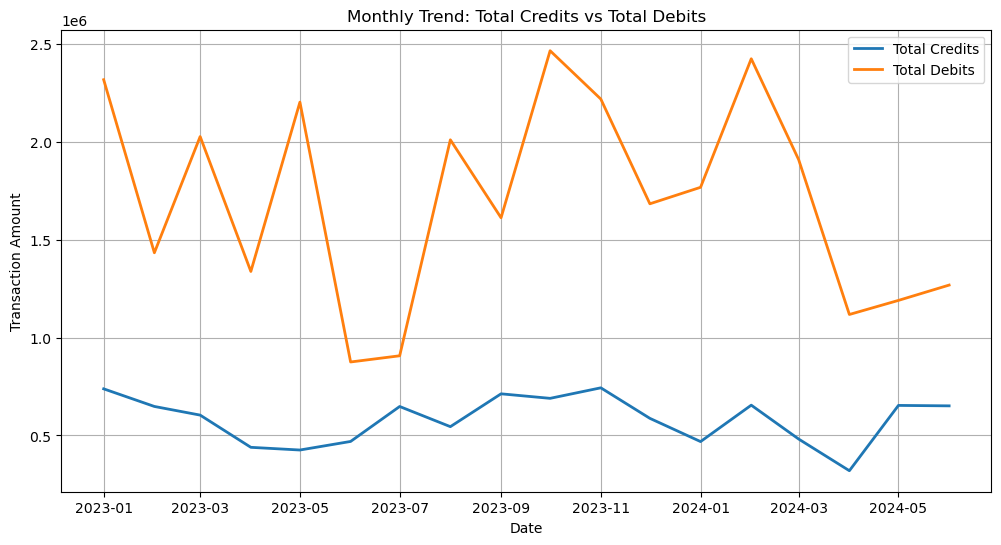

In [52]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_summary['Date'],
    monthly_summary['Total_Credits'],
    label='Total Credits',
    linewidth=2
)

plt.plot(
    monthly_summary['Date'],
    monthly_summary['Total_Debits'],
    label='Total Debits',
    linewidth=2
)

plt.title('Monthly Trend: Total Credits vs Total Debits')
plt.xlabel('Date')
plt.ylabel('Transaction Amount')
plt.legend()
plt.grid(True)

plt.show()

#### The analysis shows that debit transactions consistently exceed credit transactions across most months. This indicates a net cash outflow pattern, suggesting that customers generally withdraw or spend more funds than they deposit during the observed period.

1. Identify top and bottom performing accounts based on net inflow.

Net Inflow Calculation (Credit – Debit)

Net inflow helps us understand whether an account is depositing more or withdrawing more.
This is important for identifying:

High value accounts

Accounts showing withdrawal dominance

Accounts at risk of dropping activity

In [53]:
account_performance = df.groupby('AccountID')[['CreditAmount','DebitAmount']].sum()
account_performance = account_performance.reset_index()

In [54]:
account_performance['Net_Inflow'] = (account_performance['CreditAmount']- account_performance['DebitAmount'])

In [55]:
account_performance =account_performance.rename(columns={
    'CreditAmount': 'Total_Credits',
    'DebitAmount': 'Total_Debits'
})

In [56]:
top_accounts = account_performance.sort_values(
    by='Net_Inflow', ascending=False
).head(10)

top_accounts

,AccountID,Total_Credits,Total_Debits,Net_Inflow
92,ACC48501,346856.33960,0.00000,346856.33960
60,ACC33287,390354.42641,201236.66948,189117.75693
168,ACC87006,245497.37832,101488.36862,144009.00970
100,ACC50817,244837.13480,123447.96911,121389.16569
191,ACC99117,167040.52263,45808.22065,121232.30198
112,ACC57516,221384.17912,107219.92732,114164.25180
186,ACC95774,110414.82355,14746.31435,95668.50920
0,ACC10117,142170.20378,57310.76365,84859.44013
86,ACC45951,98505.08125,19454.38267,79050.69858
56,ACC31902,204456.94267,126739.66491,77717.27776


In [57]:
bottom_accounts = account_performance.sort_values(
    by='Net_Inflow', ascending=True
).head(10)

bottom_accounts

,AccountID,Total_Credits,Total_Debits,Net_Inflow
107,ACC53466,18181.67381,476775.484990,-458593.811180
49,ACC29396,39888.00143,442832.014120,-402944.012690
118,ACC60432,39623.16730,423334.682580,-383711.515280
48,ACC29356,27344.62435,408228.871838,-380884.247488
55,ACC31539,25819.70053,376944.670070,-351124.969540
159,ACC82298,0.00000,347376.540660,-347376.540660
165,ACC83581,39304.24834,386292.484270,-346988.235930
185,ACC95164,0.00000,340602.161780,-340602.161780
13,ACC16241,103643.14455,435968.998300,-332325.853750
99,ACC50439,0.00000,332311.198690,-332311.198690


##### Net Inflow Insights

Accounts with positive net inflow are likely depositing more money and show healthier engagement.

Accounts with highly negative net inflow may be withdrawing or becoming inactive.

Top 25% inflow accounts can be considered high-value customers.

#### There is a clear contrast between top and bottom accounts, with top performers maintaining surplus balances while bottom performers experience sustained cash depletion.

In [58]:
df.head(2)

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Year,Month,TransactionCategory,CreditAmount,DebitAmount
399,165,CUST5174,ACC18177,Loan,Withdrawal,Credit Card,Firm A,West,Manager 2,2023-01-02,38742.52123,84363.11575,0.649189,399,176,2023,1,Debit,0.0,38742.52123
86,121,CUST9248,ACC51971,Savings,Withdrawal,Home Loan,Firm C,West,Manager 3,2023-01-02,35582.48676,37466.28558,0.440967,562,224,2023,1,Debit,0.0,35582.48676


#### Identify and flag accounts as dormant or inactive if there is a gap of two months or more between consecutive transactions.

In [59]:
df = df.sort_values(['AccountID','TransactionDate'])

In [60]:
df['Prev_Transaction_Date'] = df.groupby('AccountID')['TransactionDate'].shift(1)

df['Gap_Days'] = (
    df['TransactionDate'] - df['Prev_Transaction_Date']
).dt.days

In [61]:
df.columns

Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths', 'Year', 'Month', 'TransactionCategory',
       'CreditAmount', 'DebitAmount', 'Prev_Transaction_Date', 'Gap_Days'],
      dtype='object')

In [62]:
# df['Gap_Months'] = df['Gap_Days']/ 30

In [63]:
# dormant_accounts = (
#     df.groupby('AccountID')['Gap_Months']
#     .max()
#     .reset_index()
# )

# dormant_accounts['Account_Status'] = dormant_accounts['Gap_Months'].apply(
#     lambda x: 'Dormant' if x >= 2 else 'Active'
# )

In [64]:
# df = df.merge(
#     dormant_accounts[['AccountID', 'Account_Status']],
#     on='AccountID',
#     how='left'
# )

In [65]:
# df['Account_Status'].value_counts()

In [ ]:
### As we can see There are 53 Active accounts and 747 Dormant Account

🔥 Defining Active, Inactive, and Dormant Accounts

To measure customer engagement, we create a new column AccountStatus using the following rules:

✔ Activity Criteria:

Active → Last transaction within 30 days

Inactive → Last transaction within 30–90 days

Dormant → No transaction for 90+ days

These definitions help the bank:

Identify churn risk

Target customers with offers

Prioritize high-engagement users

In [153]:
import datetime as dt

# 2. Recalculate last transaction date per account
last_txn = df.groupby('AccountID')['TransactionDate'].max().reset_index()
last_txn.rename(columns={'TransactionDate': 'Last_Transaction'}, inplace=True)

# 3. Merge
df = df.merge(last_txn, on='AccountID', how='left')

# 4. Calculate days since last transaction using today's date
today = df['TransactionDate'].max()
df['Days_Since_Last_Txn'] = (today - df['Last_Transaction']).dt.days

# 5. Define activity
def activity_status(days):
    if pd.isna(days):
        return 'Dormant'
    if days <= 30:
        return 'Active'
    elif days <= 90:
        return 'Inactive'
    else:
        return 'Dormant'

df['AccountStatus'] = df['Days_Since_Last_Txn'].apply(activity_status)

In [154]:
df['AccountStatus'].value_counts()

AccountStatus
Dormant     420
Active      235
Inactive    145
Name: count, dtype: int64

### 🎯Account Activity Distribution

After applying the activity rules based on transaction recency:

Active → Last transaction within 30 days

Inactive → Last transaction within 31–90 days

Dormant → No transactions in the last 90+ days

The distribution of customer activity levels is:

Dormant Accounts: 420

Active Accounts: 235

Inactive Accounts: 145

📝 Insights

The largest segment (420 accounts) falls under Dormant, indicating long periods without transactions. These accounts may require customer re-engagement strategies.

Active accounts (235) show regular and recent engagement, indicating healthy usage behavior.

Inactive accounts (145) represent medium-risk customers who have not transacted recently but can still be reactivated through targeted campaigns.

🎯 Business Implications

Dormant customers may be at risk of churn; targeted communication or promotional offers may help reactivate them.

Active customers could benefit from premium financial products or personalized recommendations.

Inactive customers should be monitored closely and nudged with reminders or early interventions to prevent inactivity from turning into dormancy.

#### Grouping accounts by activity levels: High, Medium, Low based on transaction frequency on your analysis and rubrics. Do not forget to mention the rubric in the headings.

### Account Activity Level Segmentation (Rubric: High ≥ 10 | Medium 5–9 | Low < 5 transactions

In [156]:
df

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,Customer_Segment,Overdraft,Frequent_Large_Withdrawal,Frequent_Overdraft,Balance_STD,Balance_CV,High_Balance_Volatility,IQR_Anomaly,Last_Transaction_y,Last_Transaction
0,73,CUST9209,ACC10117,Savings,Transfer,Credit Card,Firm E,West,Manager 1,2023-01-30,...,Low Value – Inactive,False,False,False,25886.972758,0.369249,False,False,2024-03-14,2024-03-14
1,34,CUST3109,ACC10117,Savings,Deposit,Home Loan,Firm E,West,Manager 3,2023-02-21,...,Low Value – Inactive,False,False,False,25886.972758,0.369249,False,False,2024-03-14,2024-03-14
2,106,CUST8155,ACC10117,Credit,Deposit,Mutual Fund,Firm C,East,Manager 3,2023-06-18,...,Low Value – Inactive,False,False,False,25886.972758,0.369249,False,False,2024-03-14,2024-03-14
3,169,CUST3810,ACC10117,Loan,Deposit,Home Loan,Firm B,East,Manager 4,2024-03-14,...,Low Value – Inactive,False,False,False,25886.972758,0.369249,False,False,2024-03-14,2024-03-14
4,158,CUST3041,ACC10996,Savings,Withdrawal,Credit Card,Firm B,South,Manager 3,2023-05-08,...,Low Balance – High Usage,False,False,False,9434.002316,0.216535,False,False,2024-02-09,2024-02-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,45,CUST7887,ACC99409,Current,Withdrawal,Home Loan,Firm C,Central,Manager 4,2024-03-22,...,High Balance – Low Usage,False,False,False,21429.756821,0.255896,False,False,2024-03-22,2024-03-22
796,135,CUST3015,ACC99549,Savings,Transfer,Credit Card,Firm D,East,Manager 2,2023-04-14,...,Low Value – Inactive,False,False,False,26251.797058,0.382450,False,False,2024-02-18,2024-02-18
797,195,CUST8416,ACC99549,Loan,Payment,Credit Card,Firm C,West,Manager 1,2023-08-04,...,Low Value – Inactive,False,False,False,26251.797058,0.382450,False,False,2024-02-18,2024-02-18
798,25,CUST4258,ACC99549,Loan,Transfer,Mutual Fund,Firm E,West,Manager 2,2023-10-26,...,Low Value – Inactive,False,False,False,26251.797058,0.382450,False,False,2024-02-18,2024-02-18


In [69]:
account_activity = (
    df.groupby('AccountID')
      .size()
      .reset_index(name='Transaction_Count')
)

In [70]:
def activity_level(count):
    if count >= 10:
        return 'High'
    elif count >= 5:
        return 'Medium'
    else:
        return 'Low'

In [71]:
account_activity['Activity_Level'] = (
    account_activity['Transaction_Count']
    .apply(activity_level)
)

In [72]:
account_activity['Activity_Level'].value_counts()

Activity_Level
Low       121
Medium     70
High        3
Name: count, dtype: int64

In [73]:
df = df.merge(
    account_activity[['AccountID', 'Activity_Level']],
    on='AccountID',
    how='left'
)

In [74]:
df.columns

Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths', 'Year', 'Month', 'TransactionCategory',
       'CreditAmount', 'DebitAmount', 'Prev_Transaction_Date', 'Gap_Days',
       'Last_Transaction', 'Days_Since_Last_Txn', 'AccountStatus',
       'Activity_Level'],
      dtype='object')

In [75]:
df[['AccountID', 'Activity_Level']].head()

,AccountID,Activity_Level
0,ACC10117,Low
1,ACC10117,Low
2,ACC10117,Low
3,ACC10117,Low
4,ACC10996,Medium


In [158]:
# After creating freq_balance
transaction_threshold_high = freq_balance['Transaction_Count'].quantile(0.75)
transaction_threshold_low = freq_balance['Transaction_Count'].quantile(0.25)

balance_threshold_low = freq_balance['Avg_Balance'].quantile(0.25)

# Create frequency category
def freq_category(n):
    if n >= transaction_threshold_high:
        return 'High Frequency'
    elif n <= transaction_threshold_low:
        return 'Low Frequency'
    else:
        return 'Medium Frequency'

freq_balance['Freq_Category'] = freq_balance['Transaction_Count'].apply(freq_category)

# Create balance category
freq_balance['Balance_Category'] = freq_balance['Avg_Balance'].apply(
    lambda x: 'Low Balance' if x <= balance_threshold_low else 'Normal Balance'
)


In [161]:
df = df.merge(freq_balance[['AccountID','Freq_Category','Balance_Category']], 
              on='AccountID', how='left')

In [162]:
df

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,Balance_STD,Balance_CV,High_Balance_Volatility,IQR_Anomaly,Last_Transaction_y,Last_Transaction,Freq_Category_x,Balance_Category_x,Freq_Category_y,Balance_Category_y
0,73,CUST9209,ACC10117,Savings,Transfer,Credit Card,Firm E,West,Manager 1,2023-01-30,...,25886.972758,0.369249,False,False,2024-03-14,2024-03-14,Medium Frequency,Normal Balance,Medium Frequency,Normal Balance
1,34,CUST3109,ACC10117,Savings,Deposit,Home Loan,Firm E,West,Manager 3,2023-02-21,...,25886.972758,0.369249,False,False,2024-03-14,2024-03-14,Medium Frequency,Normal Balance,Medium Frequency,Normal Balance
2,106,CUST8155,ACC10117,Credit,Deposit,Mutual Fund,Firm C,East,Manager 3,2023-06-18,...,25886.972758,0.369249,False,False,2024-03-14,2024-03-14,Medium Frequency,Normal Balance,Medium Frequency,Normal Balance
3,169,CUST3810,ACC10117,Loan,Deposit,Home Loan,Firm B,East,Manager 4,2024-03-14,...,25886.972758,0.369249,False,False,2024-03-14,2024-03-14,Medium Frequency,Normal Balance,Medium Frequency,Normal Balance
4,158,CUST3041,ACC10996,Savings,Withdrawal,Credit Card,Firm B,South,Manager 3,2023-05-08,...,9434.002316,0.216535,False,False,2024-02-09,2024-02-09,High Frequency,Low Balance,High Frequency,Low Balance
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,45,CUST7887,ACC99409,Current,Withdrawal,Home Loan,Firm C,Central,Manager 4,2024-03-22,...,21429.756821,0.255896,False,False,2024-03-22,2024-03-22,Medium Frequency,Normal Balance,Medium Frequency,Normal Balance
796,135,CUST3015,ACC99549,Savings,Transfer,Credit Card,Firm D,East,Manager 2,2023-04-14,...,26251.797058,0.382450,False,False,2024-02-18,2024-02-18,Medium Frequency,Normal Balance,Medium Frequency,Normal Balance
797,195,CUST8416,ACC99549,Loan,Payment,Credit Card,Firm C,West,Manager 1,2023-08-04,...,26251.797058,0.382450,False,False,2024-02-18,2024-02-18,Medium Frequency,Normal Balance,Medium Frequency,Normal Balance
798,25,CUST4258,ACC99549,Loan,Transfer,Mutual Fund,Firm E,West,Manager 2,2023-10-26,...,26251.797058,0.382450,False,False,2024-02-18,2024-02-18,Medium Frequency,Normal Balance,Medium Frequency,Normal Balance


### Segment customers by average balance and transaction volume.

In [76]:
customer_summary = (
    df.groupby('AccountID')
      .agg(
          Avg_Balance=('AccountBalance', 'mean'),
          Transaction_Volume=('TransactionAmount', 'sum')
      )
      .reset_index()
)


In [77]:
balance_threshold = customer_summary['Avg_Balance'].median()
volume_threshold = customer_summary['Transaction_Volume'].median()

In [78]:
def segment_customer(row):
    if row['Avg_Balance'] >= balance_threshold and row['Transaction_Volume'] >= volume_threshold:
        return 'High Value – Active'
    elif row['Avg_Balance'] >= balance_threshold and row['Transaction_Volume'] < volume_threshold:
        return 'High Balance – Low Usage'
    elif row['Avg_Balance'] < balance_threshold and row['Transaction_Volume'] >= volume_threshold:
        return 'Low Balance – High Usage'
    else:
        return 'Low Value – Inactive'

In [79]:
customer_summary['Customer_Segment'] = customer_summary.apply(
    segment_customer, axis=1
)


In [80]:
df = df.merge(
    customer_summary[['AccountID', 'Customer_Segment']],
    on='AccountID',
    how='left'
)

In [81]:
customer_summary['Customer_Segment'].value_counts()

Customer_Segment
Low Value – Inactive        49
High Value – Active         49
Low Balance – High Usage    48
High Balance – Low Usage    48
Name: count, dtype: int64

#### Create profiles for:
1. High-net inflow accounts
2. High-frequency low-balance accounts
3. Accounts with negative or near-zero balances


In [82]:
account_inflow = (
    df.groupby('AccountID').agg(
        Total_Credits = ('CreditAmount','sum'),
        Total_Debits = ('DebitAmount','sum')
    ).reset_index()
)
account_inflow['Net_Inflow'] = (
    account_inflow['Total_Credits'] - account_inflow['Total_Debits']
)

In [83]:
high_inflow_threshold = account_inflow['Net_Inflow'].quantile(0.75)
high_net_inflow_accounts = account_inflow[
account_inflow['Net_Inflow']>high_inflow_threshold
]

In [84]:
freq_balance = (
    df.groupby('AccountID')
      .agg(
          Transaction_Count=('TransactionAmount', 'count'),
          Avg_Balance=('AccountBalance', 'mean')
      )
      .reset_index()
)

In [85]:
freq_threshold = freq_balance['Transaction_Count'].quantile(0.75)
balance_threshold = freq_balance['Avg_Balance'].quantile(0.25)

In [86]:
high_freq_low_balance_accounts = freq_balance[
    (freq_balance['Transaction_Count'] >= freq_threshold) &
    (freq_balance['Avg_Balance'] <= balance_threshold)
]

In [87]:
negative_near_zero_accounts = freq_balance[
    freq_balance['Avg_Balance'] <= 5000
]

In [88]:
high_net_inflow_accounts.head(5)

,AccountID,Total_Credits,Total_Debits,Net_Inflow
0,ACC10117,142170.20378,57310.76365,84859.44013
2,ACC11062,0.00000,4014.26490,-4014.26490
7,ACC12334,149116.79761,161110.49208,-11993.69447
10,ACC15359,122856.48300,120413.19788,2443.28512
17,ACC18140,45680.91092,38542.74767,7138.16325


In [89]:
print("High-Net Inflow Accounts:", high_net_inflow_accounts.shape[0])
print("High-Frequency Low-Balance Accounts:", high_freq_low_balance_accounts.shape[0])
print("Negative / Near-Zero Balance Accounts:", negative_near_zero_accounts.shape[0])

High-Net Inflow Accounts: 49
High-Frequency Low-Balance Accounts: 15
Negative / Near-Zero Balance Accounts: 1


#### Track accounts with frequent large withdrawals or overdrafts.


In [90]:
withdrawals = df[df['TransactionType'] == 'Withdrawal'].copy()

In [91]:
large_withdrawal_threshold = withdrawals['TransactionAmount'].quantile(0.75)

print("Highest Large Withdrawals or Overdrafts : ₹",large_withdrawal_threshold.round(2))

Highest Large Withdrawals or Overdrafts : ₹ 73511.85


In [92]:
withdrawals['Large_Withdrawal'] = (
    withdrawals['TransactionAmount'] >= large_withdrawal_threshold
)

In [93]:
large_withdrawal_counts = (
    withdrawals[withdrawals['Large_Withdrawal']]
    .groupby('AccountID')
    .size()
    .reset_index(name='Large_Withdrawal_Count')
)

In [94]:
frequent_large_withdrawal_accounts = large_withdrawal_counts[
    large_withdrawal_counts['Large_Withdrawal_Count'] >= 3
]

frequent_large_withdrawal_accounts

,AccountID,Large_Withdrawal_Count


In [95]:
df['Overdraft'] = df['AccountBalance'] < 0

In [96]:
overdraft_counts = (
    df[df['Overdraft']]
    .groupby('AccountID')
    .size()
    .reset_index(name='Overdraft_Count')
)

In [97]:
frequent_overdraft_accounts = overdraft_counts[
    overdraft_counts['Overdraft_Count'] >= 2
]

frequent_overdraft_accounts

,AccountID,Overdraft_Count
5,ACC28292,2


In [98]:
risky_accounts = pd.merge(
    frequent_large_withdrawal_accounts,
    frequent_overdraft_accounts,
    on='AccountID',
    how='outer'
).fillna(0)

risky_accounts

,AccountID,Large_Withdrawal_Count,Overdraft_Count
0,ACC28292,0.0,2


In [99]:
df['Frequent_Large_Withdrawal'] = df['AccountID'].isin(
    frequent_large_withdrawal_accounts['AccountID']
)

df['Frequent_Overdraft'] = df['AccountID'].isin(
    frequent_overdraft_accounts['AccountID']
)

In [100]:
df[['AccountID', 'Frequent_Large_Withdrawal', 'Frequent_Overdraft']].drop_duplicates().head(5)

,AccountID,Frequent_Large_Withdrawal,Frequent_Overdraft
0,ACC10117,False,False
4,ACC10996,False,False
9,ACC11062,False,False
11,ACC11188,False,False
16,ACC11285,False,False


In [101]:
print("Accounts with frequent large withdrawals:",
      frequent_large_withdrawal_accounts.shape[0])

print("Accounts with frequent overdrafts:",
      frequent_overdraft_accounts.shape[0])

Accounts with frequent large withdrawals: 0
Accounts with frequent overdrafts: 1


#### Calculate balance volatility using standard deviation or coefficient of variation.

In [102]:
balance_volatility = (
    df.groupby('AccountID')
      .agg(
          Avg_Balance=('AccountBalance', 'mean'),
          Balance_STD=('AccountBalance', 'std')
      )
      .reset_index()
)

In [103]:
balance_volatility['Balance_STD'] = balance_volatility['Balance_STD'].fillna(0)

In [104]:
balance_volatility['Balance_CV'] = (
    balance_volatility['Balance_STD'] / balance_volatility['Avg_Balance'].abs()
)

In [105]:
balance_volatility.replace([float('inf'), -float('inf')], 0, inplace=True)
balance_volatility['Balance_CV'] = balance_volatility['Balance_CV'].fillna(0)

In [106]:
cv_threshold = balance_volatility['Balance_CV'].quantile(0.75)

balance_volatility['High_Balance_Volatility'] = (
    balance_volatility['Balance_CV'] >= cv_threshold
)

In [107]:
high_volatility_accounts = balance_volatility[
    balance_volatility['High_Balance_Volatility']
]

high_volatility_accounts.head(7)

,AccountID,Avg_Balance,Balance_STD,Balance_CV,High_Balance_Volatility
4,ACC11285,97401.348560,55922.732441,0.574147,True
5,ACC11837,84852.733695,60694.391957,0.715291,True
8,ACC13357,69179.806513,40614.664902,0.587088,True
13,ACC16241,73521.710375,45312.204045,0.616311,True
17,ACC18140,39960.076965,31325.244170,0.783914,True
25,ACC21878,67726.446770,70517.525297,1.041211,True
29,ACC23736,60801.533102,48785.760924,0.802377,True


In [108]:
df = df.merge(
    balance_volatility[['AccountID', 'Balance_STD', 'Balance_CV', 'High_Balance_Volatility']],
    on='AccountID',
    how='left'
)

In [109]:
df[['AccountID', 'Balance_STD', 'Balance_CV', 'High_Balance_Volatility']].drop_duplicates().head(5)

,AccountID,Balance_STD,Balance_CV,High_Balance_Volatility
0,ACC10117,25886.972758,0.369249,False
4,ACC10996,9434.002316,0.216535,False
9,ACC11062,3208.737888,0.084137,False
11,ACC11188,35494.660810,0.509599,False
16,ACC11285,55922.732441,0.574147,True


### Use IQR or z-score methods to detect anomalies

In [110]:
# Using IQR method

Q1 = df['TransactionAmount'].quantile(0.25)
Q3 = df['TransactionAmount'].quantile(0.75)

IQR = Q3 - Q1

In [111]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [112]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [113]:
df['IQR_Anomaly'] = (
    (df['TransactionAmount'] < lower_bound) |
    (df['TransactionAmount'] > upper_bound)
)

In [114]:
iqr_anomalies = df[df['IQR_Anomaly'] == True]
iqr_anomalies.head(10)

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,AccountStatus,Activity_Level,Customer_Segment,Overdraft,Frequent_Large_Withdrawal,Frequent_Overdraft,Balance_STD,Balance_CV,High_Balance_Volatility,IQR_Anomaly
103,14,CUST3015,ACC21719,Loan,Deposit,Savings Account,Firm D,North,Manager 3,2024-05-22,...,Inactive,Medium,High Value – Active,False,False,False,37271.810307,0.440479,False,True


In [115]:
iqr_anomaly_counts = (
    iqr_anomalies.groupby('AccountID')
    .size()
    .reset_index(name='IQR_Anomaly_Count')
)
iqr_anomaly_counts.head()

,AccountID,IQR_Anomaly_Count
0,ACC21719,1


### Highlight customers with irregular or suspicious transaction behavior.

In [116]:
accounts = df[['AccountID']].drop_duplicates()

In [117]:
accounts['Frequent_Large_Withdrawal'] = accounts['AccountID'].isin(
    frequent_large_withdrawal_accounts['AccountID']
)

In [118]:
accounts['Frequent_Overdraft'] = accounts['AccountID'].isin(
    frequent_overdraft_accounts['AccountID']
)

In [119]:
accounts = accounts.merge(
    balance_volatility[['AccountID', 'High_Balance_Volatility']],
    on='AccountID',
    how='left'
)

accounts['High_Balance_Volatility'] = (
    accounts['High_Balance_Volatility'].fillna(False)
)

In [120]:
accounts = accounts.merge(
    iqr_anomaly_counts,
    on='AccountID',
    how='left'
)

accounts['IQR_Anomaly_Count'] = accounts['IQR_Anomaly_Count'].fillna(0)

accounts['High_Anomaly'] = accounts['IQR_Anomaly_Count'] >= 2

In [121]:
accounts['Risk_Score'] = (
    accounts['Frequent_Large_Withdrawal'].astype(int) +
    accounts['Frequent_Overdraft'].astype(int) +
    accounts['High_Balance_Volatility'].astype(int) +
    accounts['High_Anomaly'].astype(int)
)

In [122]:
accounts['Suspicious_Account'] = accounts['Risk_Score'] >= 2

In [123]:
suspicious_accounts = accounts[accounts['Suspicious_Account']]
suspicious_accounts.head(5)

,AccountID,Frequent_Large_Withdrawal,Frequent_Overdraft,High_Balance_Volatility,IQR_Anomaly_Count,High_Anomaly,Risk_Score,Suspicious_Account
42,ACC28292,False,True,True,0.0,False,2,True


In [124]:
suspicious_accounts['Risk_Score'].value_counts()

Risk_Score
2    1
Name: count, dtype: int64

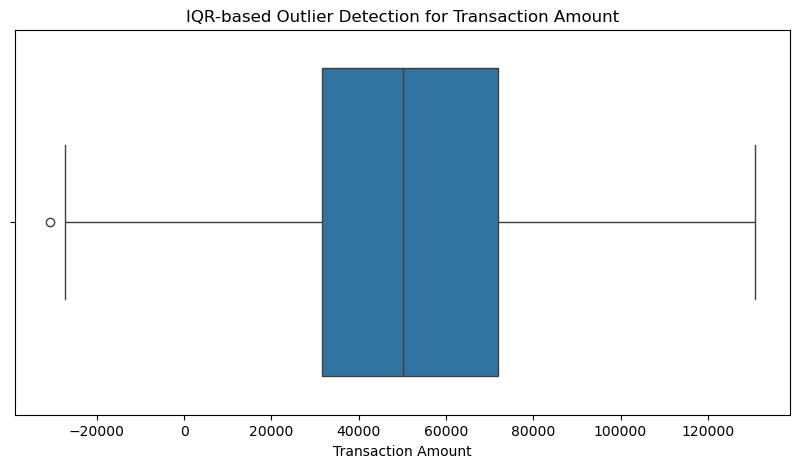

In [125]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['TransactionAmount'])
plt.title('IQR-based Outlier Detection for Transaction Amount')
plt.xlabel('Transaction Amount')
plt.show()

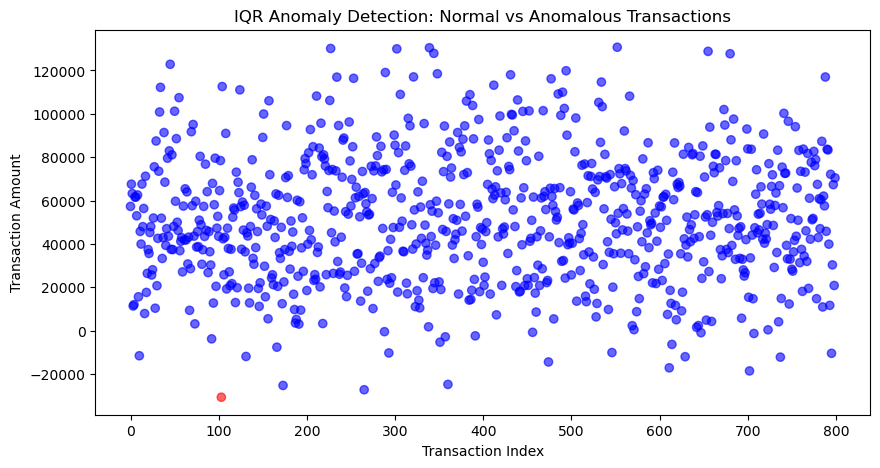

In [126]:
plt.figure(figsize=(10,5))

plt.scatter(
    df.index,
    df['TransactionAmount'],
    c=df['IQR_Anomaly'].map({True: 'red', False: 'blue'}),
    alpha=0.6
)

plt.title('IQR Anomaly Detection: Normal vs Anomalous Transactions')
plt.xlabel('Transaction Index')
plt.ylabel('Transaction Amount')
plt.show()


 IQR-Based Anomaly Detection Visualization

 The Interquartile Range (IQR) method was used to identify anomalous transaction amounts.  
 Visualizations were created to highlight extreme values and compare normal and anomalous transactions.


### Conduct extensive exploratory data analysis with attractive visualizations for your findings

#### To understand how transaction values are spread and identify skewness or extreme values.

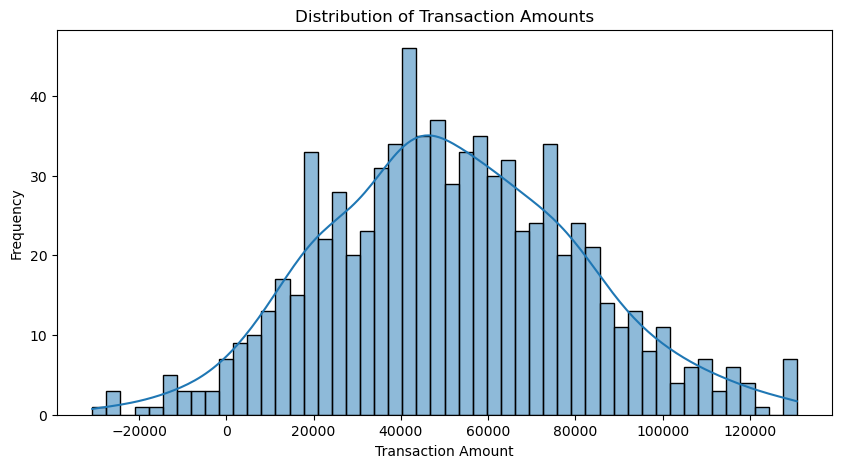

In [127]:
plt.figure(figsize=(10,5))
sns.histplot(df['TransactionAmount'],bins=50, kde=True)
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

#### To understand which transaction types dominate customer activity.

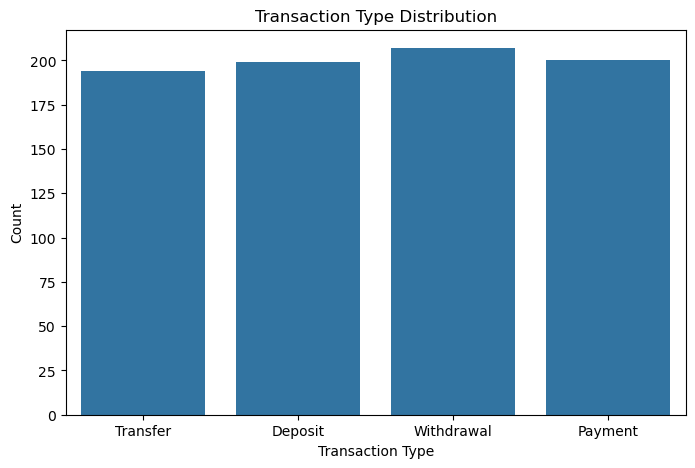

In [128]:
plt.figure(figsize=(8,5))
sns.countplot(x='TransactionType',data=df)
plt.title('Transaction Type Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

#### To visualize inflow vs outflow trends over time.

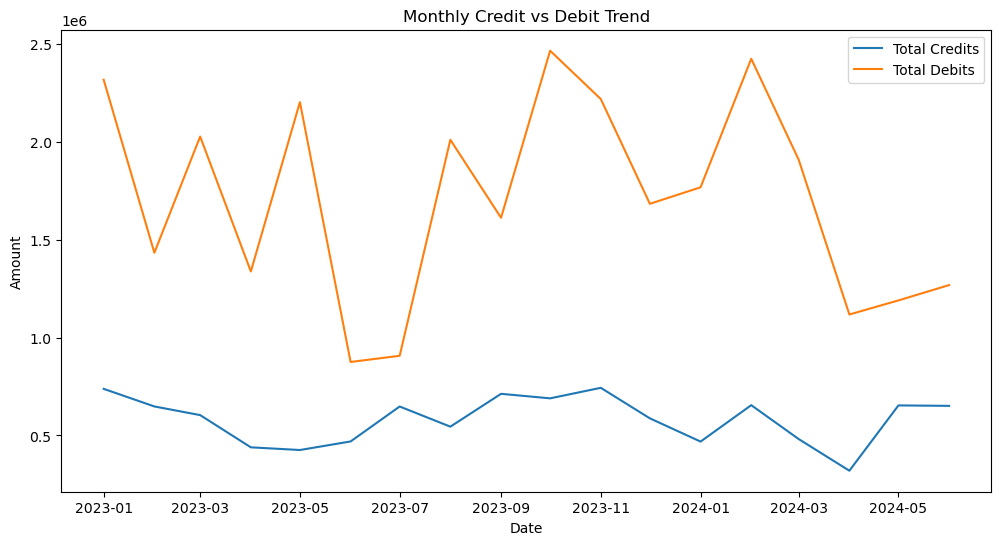

In [129]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_summary['Date'],
    monthly_summary['Total_Credits'],
    label='Total Credits'
)

plt.plot(
    monthly_summary['Date'],
    monthly_summary['Total_Debits'],
    label='Total Debits'
)

plt.legend()
plt.title('Monthly Credit vs Debit Trend')
plt.xlabel('Date')
plt.ylabel('Amount')
plt.show()

In [130]:
df.columns

Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths', 'Year', 'Month', 'TransactionCategory',
       'CreditAmount', 'DebitAmount', 'Prev_Transaction_Date', 'Gap_Days',
       'Last_Transaction', 'Days_Since_Last_Txn', 'AccountStatus',
       'Activity_Level', 'Customer_Segment', 'Overdraft',
       'Frequent_Large_Withdrawal', 'Frequent_Overdraft', 'Balance_STD',
       'Balance_CV', 'High_Balance_Volatility', 'IQR_Anomaly'],
      dtype='object')

### Rubric: High ≥ 10 | Medium 5–9 | Low < 5 transactions

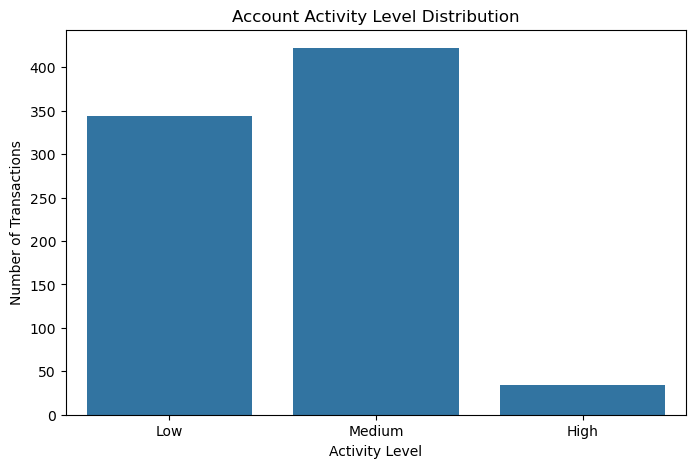

In [131]:
plt.figure(figsize=(8,5))
sns.countplot(x='Activity_Level', data=df)
plt.title('Account Activity Level Distribution')
plt.xlabel('Activity Level')
plt.ylabel('Number of Transactions')
plt.show()

### Average Balance vs Transaction Volume

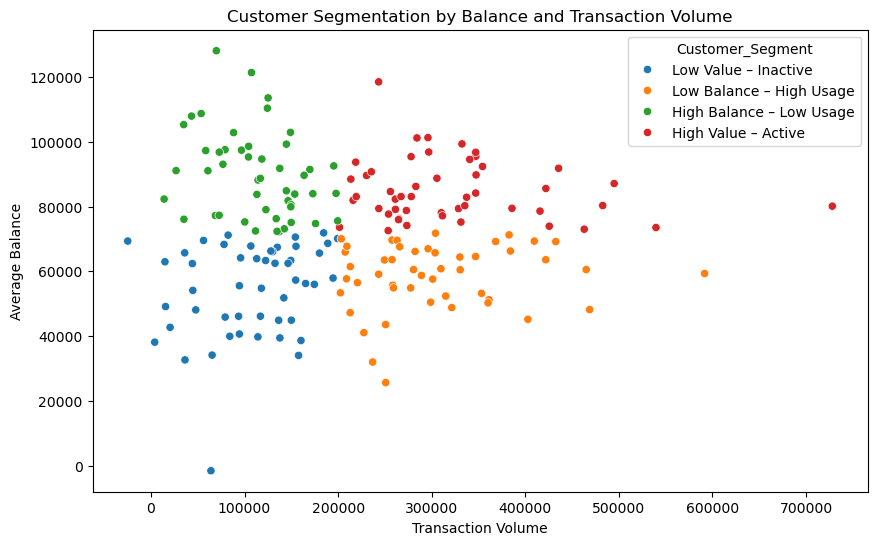

In [132]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='Transaction_Volume',
    y='Avg_Balance',
    hue='Customer_Segment',
    data=customer_summary
)
plt.title('Customer Segmentation by Balance and Transaction Volume')
plt.xlabel('Transaction Volume')
plt.ylabel('Average Balance')
plt.show()

#### Balance Volatility Distribution

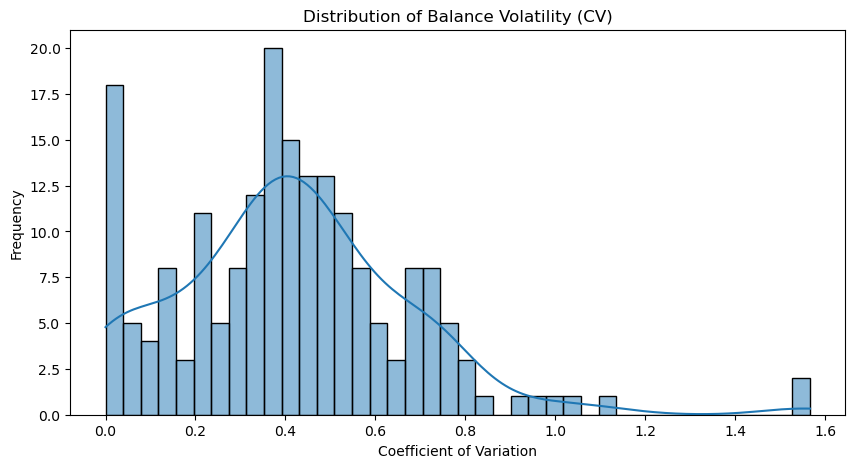

In [133]:
plt.figure(figsize=(10,5))
sns.histplot(balance_volatility['Balance_CV'], bins=40, kde=True)
plt.title('Distribution of Balance Volatility (CV)')
plt.xlabel('Coefficient of Variation')
plt.ylabel('Frequency')
plt.show()

#### Anomalous Transactions Visualization

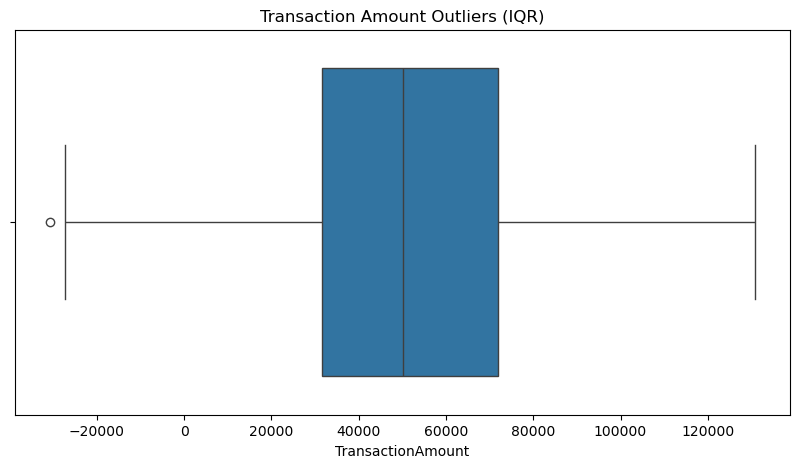

In [134]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['TransactionAmount'])
plt.title('Transaction Amount Outliers (IQR)')
plt.show()

### Risk Indicator Contribution

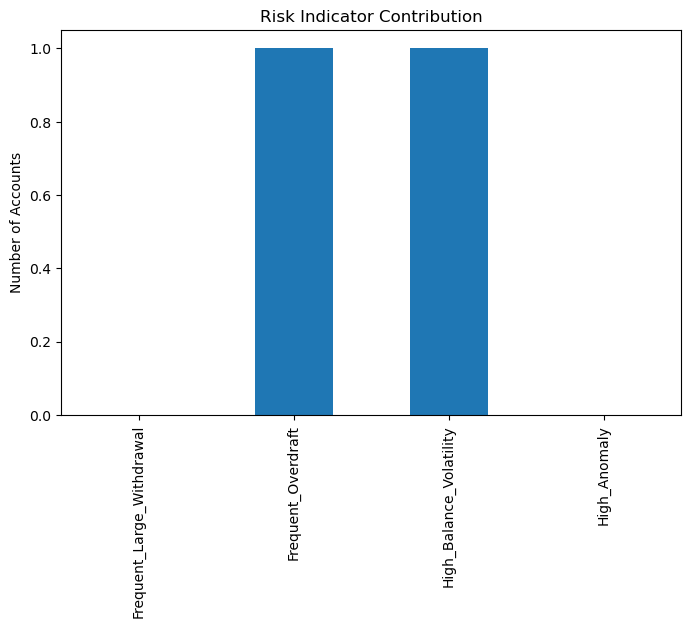

In [135]:
risk_counts = suspicious_accounts[
    ['Frequent_Large_Withdrawal', 'Frequent_Overdraft',
     'High_Balance_Volatility', 'High_Anomaly']
].sum()

plt.figure(figsize=(8,5))
risk_counts.plot(kind='bar')
plt.title('Risk Indicator Contribution')
plt.ylabel('Number of Accounts')
plt.show()

### Hypothesis Testing 

In [136]:
account_stats = (
    df.groupby('AccountID')
      .agg(
          Avg_Balance=('AccountBalance', 'mean'),
          Transaction_Volume=('TransactionAmount', 'sum')
      )
      .reset_index()
)

In [137]:
volume_threshold = account_stats['Transaction_Volume'].median()

high_volume_accounts = account_stats[
    account_stats['Transaction_Volume'] > volume_threshold
]['Avg_Balance']

low_volume_accounts = account_stats[
    account_stats['Transaction_Volume'] <= volume_threshold
]['Avg_Balance']

In [138]:
## Performing Hypothesis Testing 
from scipy.stats import ttest_ind

In [139]:
t_stat, p_value = ttest_ind(
    high_volume_accounts,
    low_volume_accounts,
    equal_var=False   # Welch’s t-test (safer)
)
t_stat, p_value

(-0.08733149845245664, 0.9305072815617675)

In [140]:
alpha = 0.05

if p_value < alpha:

    print("Reject the null hypothesis: High-volume accounts have significantly higher average balances.")
else:
    
    print("Fail to reject the null hypothesis: No significant difference in average balances.")

Fail to reject the null hypothesis: No significant difference in average balances.


In [141]:
print("High-volume average balance: ₹", high_volume_accounts.mean().round(2))
print("Low-volume average balance: ₹", low_volume_accounts.mean().round(2))

High-volume average balance: ₹ 71871.43
Low-volume average balance: ₹ 72118.95


### Visual Comparison

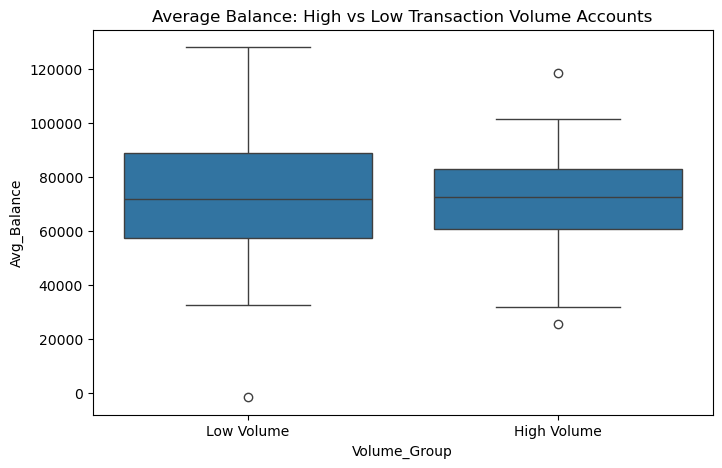

In [142]:
plot_data = account_stats.copy()
plot_data['Volume_Group'] = plot_data['Transaction_Volume'].apply(
    lambda x: 'High Volume' if x > volume_threshold else 'Low Volume'
)

plt.figure(figsize=(8,5))
sns.boxplot(x='Volume_Group', y='Avg_Balance', data=plot_data)
plt.title('Average Balance: High vs Low Transaction Volume Accounts')
plt.show()

### Conduct hypothesis testing based on segmentation.

Hypothesis testing was conducted to validate differences observed across customer segments.
Accounts were segmented based on transaction volume, and an independent t-test was applied to compare average balances between high-volume and low-volume groups.
This approach ensured that observed differences were statistically significant and not due to random variation.